# PSID Generic Crisis Module — NLP Optimization Pipeline v2

**Project:** Panel Study of Income Dynamics (PSID)
**Directed by:** Thomas Crossley
**Team:** PSID Survey Methodology Group
**Version:** Updated with Hurricane Katrina Module

---

## Objective

This notebook implements a **Natural Language Processing (NLP)** and
**mathematical optimization** pipeline to rank historical PSID survey
questions for inclusion in a pre-specified **Generic Crisis Module**.

The pipeline:

1. **Loads** a Katrina-integrated ranked-question CSV covering shutdown,
   pandemic, demographic, and Hurricane Katrina crisis-module content.
2. **Parses or extracts keywords** using the shared pipeline module, with
   precomputed keyword lists reused when they are already present.
3. **Tags keywords** against a hand-curated crisis-construct taxonomy
   with predetermined impact weights.
4. **Scores every question** using the Utility-Burden formulation:

$$R_i = \frac{U_i}{B_i}$$

where $U_i = \sum_{k \in K_i} w_k$ and $B_i = \alpha N_i + \beta C_i$.

5. **Visualises** results so leadership can finalise the module.

## 1. Environment Setup

In [46]:
# ──────────────────────────────────────────────────────────────────────────
# 1.  IMPORTS & CONFIGURATION
# ──────────────────────────────────────────────────────────────────────────
import importlib
import warnings
warnings.filterwarnings("ignore")

import textwrap

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

import PSID_NLP_Crisis_Module_Structure as pipeline
pipeline = importlib.reload(pipeline)

# Seaborn style
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
})

print("Environment ready.")
print("Pipeline module loaded.")

Environment ready.
Pipeline module loaded.


## 2. Data Ingestion

We load questions from a **single pre-built ranked CSV** stored in the workspace.
The file already consolidates the historical PSID sources and the
**Hurricane Katrina 2007 supplement**, which captures crisis content tied to
the **Hurricane Katrina 2005** event.

| Source file | Section | Content |
|---|---|---|
| `PSID_Ranked_Questions_Katrina_Integrated.csv` | Ranked export | Government shutdown income and coping questions |
| `PSID_Ranked_Questions_Katrina_Integrated.csv` | Ranked export | COVID-19 economic-impact items |
| `PSID_Ranked_Questions_Katrina_Integrated.csv` | Ranked export | Understanding Society baseline demographics |
| `PSID_Ranked_Questions_Katrina_Integrated.csv` | Ranked export | Hurricane Katrina 2007 supplement items for the 2005 disaster context |

Notebook-side normalization restores the canonical column names used by the
downstream analysis.

In [47]:
# ──────────────────────────────────────────────────────────────────────────
# 2.  DATA INGESTION — load Katrina-integrated ranked questions from CSV
# ──────────────────────────────────────────────────────────────────────────

CSV_PATH = "/Users/namomac/Team-PSID/PSID_Ranked_Questions_Katrina_Integrated.csv"

df = pd.read_csv(CSV_PATH)
df = df.rename(columns=pipeline.COLUMN_RENAME_MAP)

if "keywords" in df.columns:
    df["keywords"] = df["keywords"].apply(pipeline.parse_keywords)

if "toggle_category" in df.columns:
    df["toggle_category"] = df["toggle_category"].replace(pipeline.TOGGLE_LABEL_MAP)

df["crisis_origin"] = df["source"].map(pipeline.SOURCE_TO_CRISIS_ORIGIN).fillna(df["source"])

print(f"Total questions ingested: {len(df)}")
print(df["source"].value_counts().to_string())
df.head(10)

Total questions ingested: 52
source
Hurricane Katrina 2007    37
COVID-19                   8
Govt Shutdown Income       3
Understanding Society      3
Govt Shutdown Crisis       1


,question_text,source,module_type,toggle_category,keywords,n_keywords,n_tagged,word_count,complexity,Ui,Bi,Ri,selected_for_module,crisis_origin
0,Was your home damaged or destroyed by Katrina ...,Hurricane Katrina 2007,Crisis-Specific,Toggle: Pandemic / Disaster,"[damaged, destroyed, home, katrina, rita, your...",6,6,10,0.0,5.70,1.0,5.70,True,Hurricane Katrina 2005
1,Was your business damaged or destroyed by Katr...,Hurricane Katrina 2007,Crisis-Specific,Toggle: Pandemic / Disaster,"[business, damaged, destroyed, katrina, rita, ...",6,6,10,0.0,5.70,1.0,5.70,True,Hurricane Katrina 2005
2,Any financial difficulties,COVID-19,Crisis-Specific,Generic Core,"[any financial difficulties, financial difficu...",2,2,3,0.0,1.70,0.3,5.67,True,COVID-19 2021
3,Lost earnings because of the pandemic,COVID-19,Crisis-Specific,Toggle: Pandemic / Disaster,"[earnings, lost earnings, pandemic, the pandemic]",4,4,6,0.0,3.40,0.6,5.67,True,COVID-19 2021
4,Only work from home,COVID-19,Crisis-Specific,Toggle: Pandemic / Disaster,"[home, only work, work]",3,3,4,0.0,2.25,0.4,5.63,True,COVID-19 2021
5,stopped this work?,Govt Shutdown Income,Generic,Generic Core,"[stopped, this work, work]",3,3,4,0.0,2.15,0.4,5.38,True,Shutdown 2019
6,Were/Was there any wages or salarys from this ...,Govt Shutdown Income,Generic,Generic Core,"[this job, any wages, job, jobs, salary, salar...",8,8,10,0.5,5.70,1.1,5.18,True,Shutdown 2019
7,Was anyone in your immediate family killed as ...,Hurricane Katrina 2007,Crisis-Specific,Toggle: Pandemic / Disaster,"[anyone, family, immediate family, katrina, ki...",7,7,13,0.0,6.65,1.3,5.12,True,Hurricane Katrina 2005
8,Did you experience hurricane force winds at yo...,Hurricane Katrina 2007,Crisis-Specific,Toggle: Pandemic / Disaster,"[experience, force winds, hurricane, katrina, ...",7,7,13,0.0,6.65,1.3,5.12,True,Hurricane Katrina 2005
9,Did you experience major flooding in your home...,Hurricane Katrina 2007,Crisis-Specific,Toggle: Pandemic / Disaster,"[experience, flooding, home, katrina, major fl...",7,7,12,0.0,5.70,1.2,4.75,True,Hurricane Katrina 2005


## 3. NLP Pipeline — Keyword Extraction

The ranked CSV already contains a **precomputed keywords** column, so the
notebook reuses those values when available. If that field is missing, the
shared pipeline module can still re-run the original dual extractor:

1. **RAKE** — scores multi-word keyphrases by co-occurrence frequency
   and degree (prefers longer, rarer phrases).
2. **spaCy noun-phrase chunking** — captures compact noun phrases that
   RAKE sometimes splits.

This keeps the workflow reproducible while avoiding redundant NLP work on the
integrated Katrina dataset.

In [48]:
# ──────────────────────────────────────────────────────────────────────────
# 3.  NLP PIPELINE — reuse precomputed keywords when available
# ──────────────────────────────────────────────────────────────────────────

if "keywords" in df.columns and df["keywords"].apply(bool).any():
    df["keywords"] = df["keywords"].apply(pipeline.parse_keywords)
else:
    df["keywords"] = df["question_text"].apply(pipeline.extract_keywords)

df["n_keywords"] = df["keywords"].apply(len)

print("Sample keyword extraction / parsing:")
sample_indices = list(df.index[:4])
katrina_matches = df.index[df["source"].str.contains("Katrina", case=False, na=False)].tolist()
if katrina_matches:
    sample_indices.append(katrina_matches[0])
sample_indices = list(dict.fromkeys(sample_indices))[:5]

for idx in sample_indices:
    row = df.loc[idx]
    print(f"  Source: {row['source']}")
    print(f"  Q: {row['question_text'][:100]}...")
    print(f"     Keywords: {row['keywords'][:6]}")
    print()

Sample keyword extraction / parsing:
  Source: Hurricane Katrina 2007
  Q: Was your home damaged or destroyed by Katrina or Rita?...
     Keywords: ['damaged', 'destroyed', 'home', 'katrina', 'rita', 'your home']

  Source: Hurricane Katrina 2007
  Q: Was your business damaged or destroyed by Katrina or Rita?...
     Keywords: ['business', 'damaged', 'destroyed', 'katrina', 'rita', 'your business']

  Source: COVID-19
  Q: Any financial difficulties...
     Keywords: ['any financial difficulties', 'financial difficulties']

  Source: COVID-19
  Q: Lost earnings because of the pandemic...
     Keywords: ['earnings', 'lost earnings', 'pandemic', 'the pandemic']



## 4. Semantic Taxonomy & Impact Weights

Each keyword is mapped to one or more **crisis constructs**. The impact
weight $w_k$ reflects how analytically valuable that keyword is for
measuring crisis effects. The shared pipeline taxonomy now includes the
Katrina expansion used in the integrated CSV.

| Construct | Weight | Example keywords |
|---|---|---|
| Economic / Income | 0.80 | income, earnings, wages, receipts |
| Employment | 0.75 | furloughed, laid off, working, job |
| Financial Coping | 0.85 | savings, credit card, retirement, food bank |
| Housing / Shelter | 0.90-0.95 | rent, mortgage, home, flooding, displaced, levee |
| Government Aid | 0.60-0.75 | stimulus, unemployment insurance, paycheck protection, FEMA |
| Trauma / Health | 0.85-0.95 | pandemic, hurricane, katrina, injured, nightmares |
| Demographics | 0.40-0.50 | age, sex, date of birth, resident |

In [49]:
# ──────────────────────────────────────────────────────────────────────────
# 4.  SEMANTIC TAXONOMY — keyword → construct → impact weight
# ──────────────────────────────────────────────────────────────────────────

TAXONOMY = pipeline.TAXONOMY
tag_keywords = pipeline.tag_keywords

df["tagged"] = df["keywords"].apply(tag_keywords)
df["n_tagged"] = df["tagged"].apply(len)
df["constructs"] = df["tagged"].apply(pipeline.extract_constructs)

all_tags = []
for _, row in df.iterrows():
    for tag in row["tagged"]:
        all_tags.append({**tag, "source": row["source"]})

tag_df = pd.DataFrame(all_tags)
if len(tag_df):
    print("Construct distribution across all questions:")
    print(tag_df["construct"].value_counts().to_string())

    katrina_constructs = tag_df[
        tag_df["source"].str.contains("Katrina", case=False, na=False)
    ]["construct"].value_counts()
    if not katrina_constructs.empty:
        print("\nHurricane Katrina construct distribution:")
        print(katrina_constructs.to_string())

Construct distribution across all questions:
construct
Trauma / Health      80
Employment           15
Government Aid       12
Housing / Shelter    11
Financial Coping      9
Economic / Income     8
Demographics          7

Hurricane Katrina construct distribution:
construct
Trauma / Health      76
Housing / Shelter    11
Government Aid        6
Economic / Income     2
Employment            2
Financial Coping      1


## 5. Mathematical Optimization — Utility-Burden Ranking

### Formulation

For each question *i*:

**U_i = sum of w_k** (Information Utility)

**B_i = alpha * N_i + beta * C_i** (Respondent Burden)

**R_i = U_i / B_i** (Ranking Score — higher is better)

| Symbol | Meaning | Default |
|---|---|---|
| w_k | Impact weight of keyword k from taxonomy | see above |
| N_i | Word count of question i | — |
| C_i | Structural complexity (unique entity count via spaCy NER) | — |
| alpha | Word-length penalty coefficient | 0.10 |
| beta | Complexity penalty coefficient | 0.20 |

In [50]:
# ──────────────────────────────────────────────────────────────────────────
# 5.  UTILITY-BURDEN SCORING
# ──────────────────────────────────────────────────────────────────────────

ALPHA = pipeline.ALPHA
BETA = pipeline.BETA
compute_word_count = pipeline.compute_word_count
compute_complexity = pipeline.compute_complexity
compute_utility = pipeline.compute_utility
compute_burden = pipeline.compute_burden

df["word_count"] = df["question_text"].apply(compute_word_count)
df["complexity"] = df["question_text"].apply(compute_complexity)
df["Ui"] = df["tagged"].apply(compute_utility)
df["Bi"] = df.apply(
    lambda row: compute_burden(row["word_count"], row["complexity"]),
    axis=1,
 )
df["Ri"] = df["Ui"] / df["Bi"]

df = df.sort_values("Ri", ascending=False).reset_index(drop=True)

print("Top 15 questions by Ranking Score (Ri):")
print()
display_cols = [
    "question_text",
    "source",
    "crisis_origin",
    "module_type",
    "Ui",
    "Bi",
    "Ri",
]
print(
    df[display_cols]
    .head(15)
    .to_string(
        index=True,
        max_colwidth=70,
        float_format=lambda value: f"{value:.3f}",
    )
)

Top 15 questions by Ranking Score (Ri):

                                                            question_text                  source           crisis_origin      module_type    Ui    Bi    Ri
0                                              Any financial difficulties                COVID-19           COVID-19 2021  Crisis-Specific 1.700 0.300 5.667
1                                   Lost earnings because of the pandemic                COVID-19           COVID-19 2021  Crisis-Specific 3.400 0.600 5.667
2                                                      stopped this work?    Govt Shutdown Income           Shutdown 2019          Generic 1.400 0.300 4.667
3                                               Received stimulus payment                COVID-19           COVID-19 2021  Crisis-Specific 1.400 0.300 4.667
4                                       stopped working at this business?    Govt Shutdown Income           Shutdown 2019          Generic 2.250 0.500 4.500
5                

## 6. Toggle Logic — Generic Core vs Crisis-Specific Subsets

The highest-ranked questions are partitioned:

* **Generic Core** — questions applicable to *any* crisis (demographics,
  financial coping, employment disruption). These form the permanent
  backbone of the module.
* **Toggle: Financial Crisis** — items specific to government shutdowns,
  recessions, or fiscal shocks.
* **Toggle: Pandemic / Disaster** — items about health, evacuation,
  structural damage, FEMA assistance, and Hurricane Katrina exposure.

In [51]:
# ──────────────────────────────────────────────────────────────────────────
# 6.  TOGGLE CLASSIFICATION
# ──────────────────────────────────────────────────────────────────────────

classify_toggle = pipeline.classify_toggle

df["toggle_category"] = df.apply(classify_toggle, axis=1)

print("Toggle distribution:")
print(df["toggle_category"].value_counts().to_string())
print()

for cat in df["toggle_category"].dropna().unique():
    subset = df[df["toggle_category"] == cat].head(5)
    print(f"\n── {cat} (top 5) ──")
    for _, row in subset.iterrows():
        print(f"  Ri={row['Ri']:.3f}  {row['question_text'][:75]}")

Toggle distribution:
toggle_category
Toggle: Pandemic / Disaster    44
Generic Core                    7
Toggle: Financial Crisis        1


── Generic Core (top 5) ──
  Ri=5.667  Any financial difficulties
  Ri=4.667  stopped this work?
  Ri=4.500  stopped working at this business?
  Ri=2.727  Were/Was there any wages or salarys from this job/these jobs?
  Ri=1.667  Calculate respondents age

── Toggle: Pandemic / Disaster (top 5) ──
  Ri=5.667  Lost earnings because of the pandemic
  Ri=4.667  Received stimulus payment
  Ri=4.000  Working in a job that was considered essential work?
  Ri=3.500  Only work from home
  Ri=3.500  Stimulus payments

── Toggle: Financial Crisis (top 5) ──
  Ri=3.719  How did you/your family manage any financial difficulties due to the shutdo


## 7. Time-Constraint Validation

The client mandates a **30-minute maximum** with a **5–15 minute ideal**.
We estimate survey duration by assuming **~7 seconds per word** (average
for CATI/Web mixed-mode reading + response time). The final assembly now
anchors the **Generic Core** first, then fills the remaining budget with the
highest-ranked crisis-specific toggle questions.

In [52]:
# ──────────────────────────────────────────────────────────────────────────
# 7.  TIMING CONSTRAINT CHECK
# ──────────────────────────────────────────────────────────────────────────

SECS_PER_WORD = pipeline.SECS_PER_WORD
MAX_SECONDS = pipeline.MAX_SECONDS
IDEAL_SECONDS = pipeline.IDEAL_SECONDS

df = pipeline.select_for_time_budget(df)
selected_df = df[df["selected_for_module"]].copy()

cumulative_secs = int(selected_df["word_count"].sum() * SECS_PER_WORD)
total_mins = cumulative_secs / 60
n_selected = len(selected_df)

print(f"Questions selected for module: {n_selected}")
print(f"Estimated total duration:      {total_mins:.1f} minutes")
print(f"Hard cap:                      {MAX_SECONDS / 60:.1f} minutes")
print(f"Ideal target:                  5-15 minutes")
print(
    f"Status: {'WITHIN IDEAL' if total_mins <= IDEAL_SECONDS / 60 else 'WITHIN 30-MIN CAP' if total_mins <= MAX_SECONDS / 60 else 'EXCEEDS CAP'}"
)
print("Core-first selection order applied.")

for cat in sorted(selected_df["toggle_category"].unique()):
    sub = selected_df[selected_df["toggle_category"] == cat]
    cat_mins = sub["word_count"].sum() * SECS_PER_WORD / 60
    print(f"  {cat}: {len(sub)} questions, ~{cat_mins:.1f} min")

Questions selected for module: 28
Estimated total duration:      29.9 minutes
Hard cap:                      30.0 minutes
Ideal target:                  5-15 minutes
Status: WITHIN 30-MIN CAP
Core-first selection order applied.
  Generic Core: 7 questions, ~4.9 min
  Toggle: Financial Crisis: 1 questions, ~1.9 min
  Toggle: Pandemic / Disaster: 20 questions, ~23.1 min


## 8. Visualisations

### 8a. Top-Ranked Questions — Overall

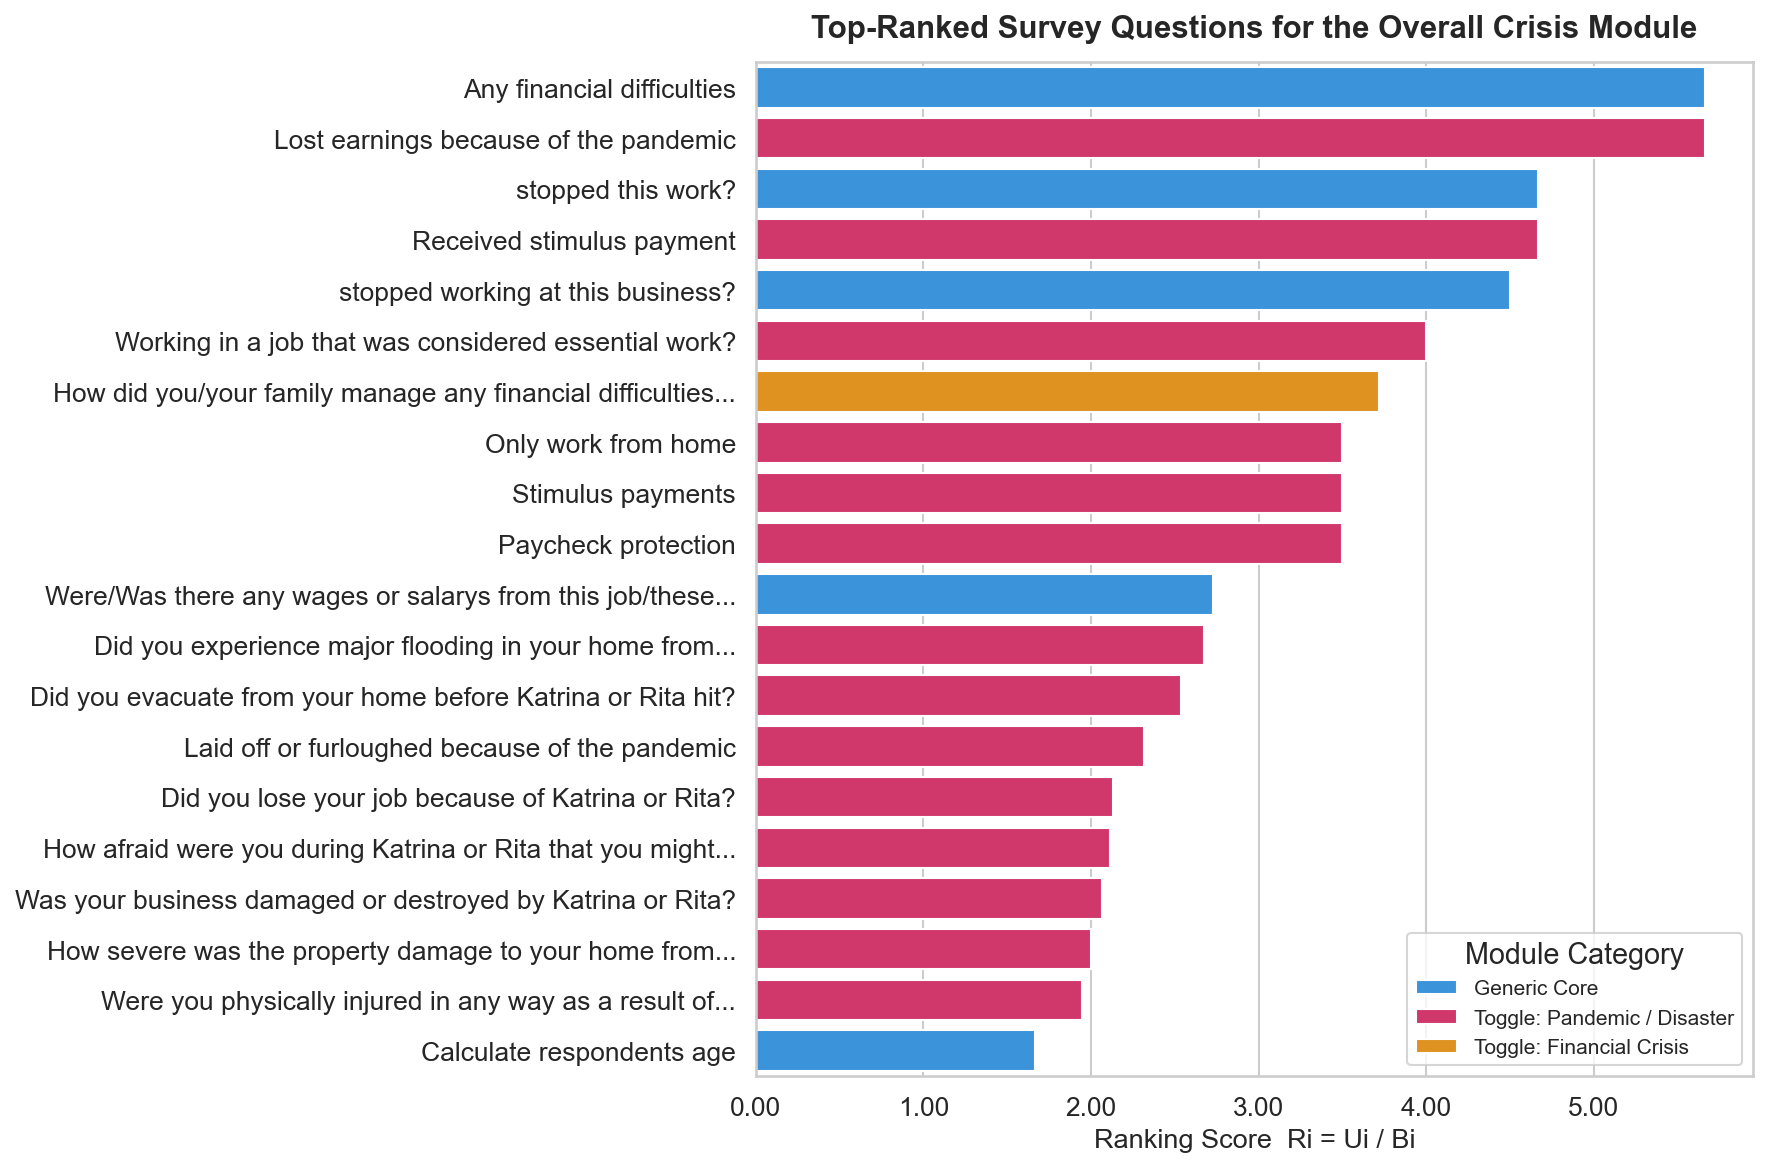

Saved: fig_top_ranked_questions.png


In [59]:
# ──────────────────────────────────────────────────────────────────────────
# 8a. BAR CHART — Top 20 questions by Ranking Score (Ri)
# ──────────────────────────────────────────────────────────────────────────

top_n = min(20, len(df))
plot_df = df.head(top_n).copy()
plot_df["short_q"] = plot_df["question_text"].apply(
    lambda text: textwrap.shorten(text, width=60, placeholder="...")
)

toggle_palette = {
    "Generic Core": "#2196F3",
    "Toggle: Financial Crisis": "#FF9800",
    "Toggle Financial Crisis": "#FF9800",
    "Toggle: Pandemic / Disaster": "#E91E63",
    "Toggle Pandemic Disaster": "#E91E63",
    "Toggle Natural Disaster": "#9C27B0",
}
crisis_origin_palette = {
    "Shutdown 2019": "#FF9800",
    "COVID-19 2021": "#E91E63",
    "Understanding Society": "#2196F3",
    "Hurricane Katrina 2005": "#00695C",
}

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    y="short_q",
    x="Ri",
    hue="toggle_category",
    dodge=False,
    palette=toggle_palette,
    ax=ax,
 )
ax.set_xlabel("Ranking Score  Ri = Ui / Bi", fontsize=13)
ax.set_ylabel("")
ax.set_title(
    "Top-Ranked Survey Questions for the Overall Crisis Module",
    fontsize=15,
    fontweight="bold",
    pad=12,
 )
ax.legend(title="Module Category", loc="lower right", fontsize=10)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
plt.tight_layout()
plt.savefig("fig_top_ranked_questions.png", bbox_inches="tight")
plt.show()
print("Saved: fig_top_ranked_questions.png")

### 8b. Generic Core vs Crisis-Specific Toggle Comparison

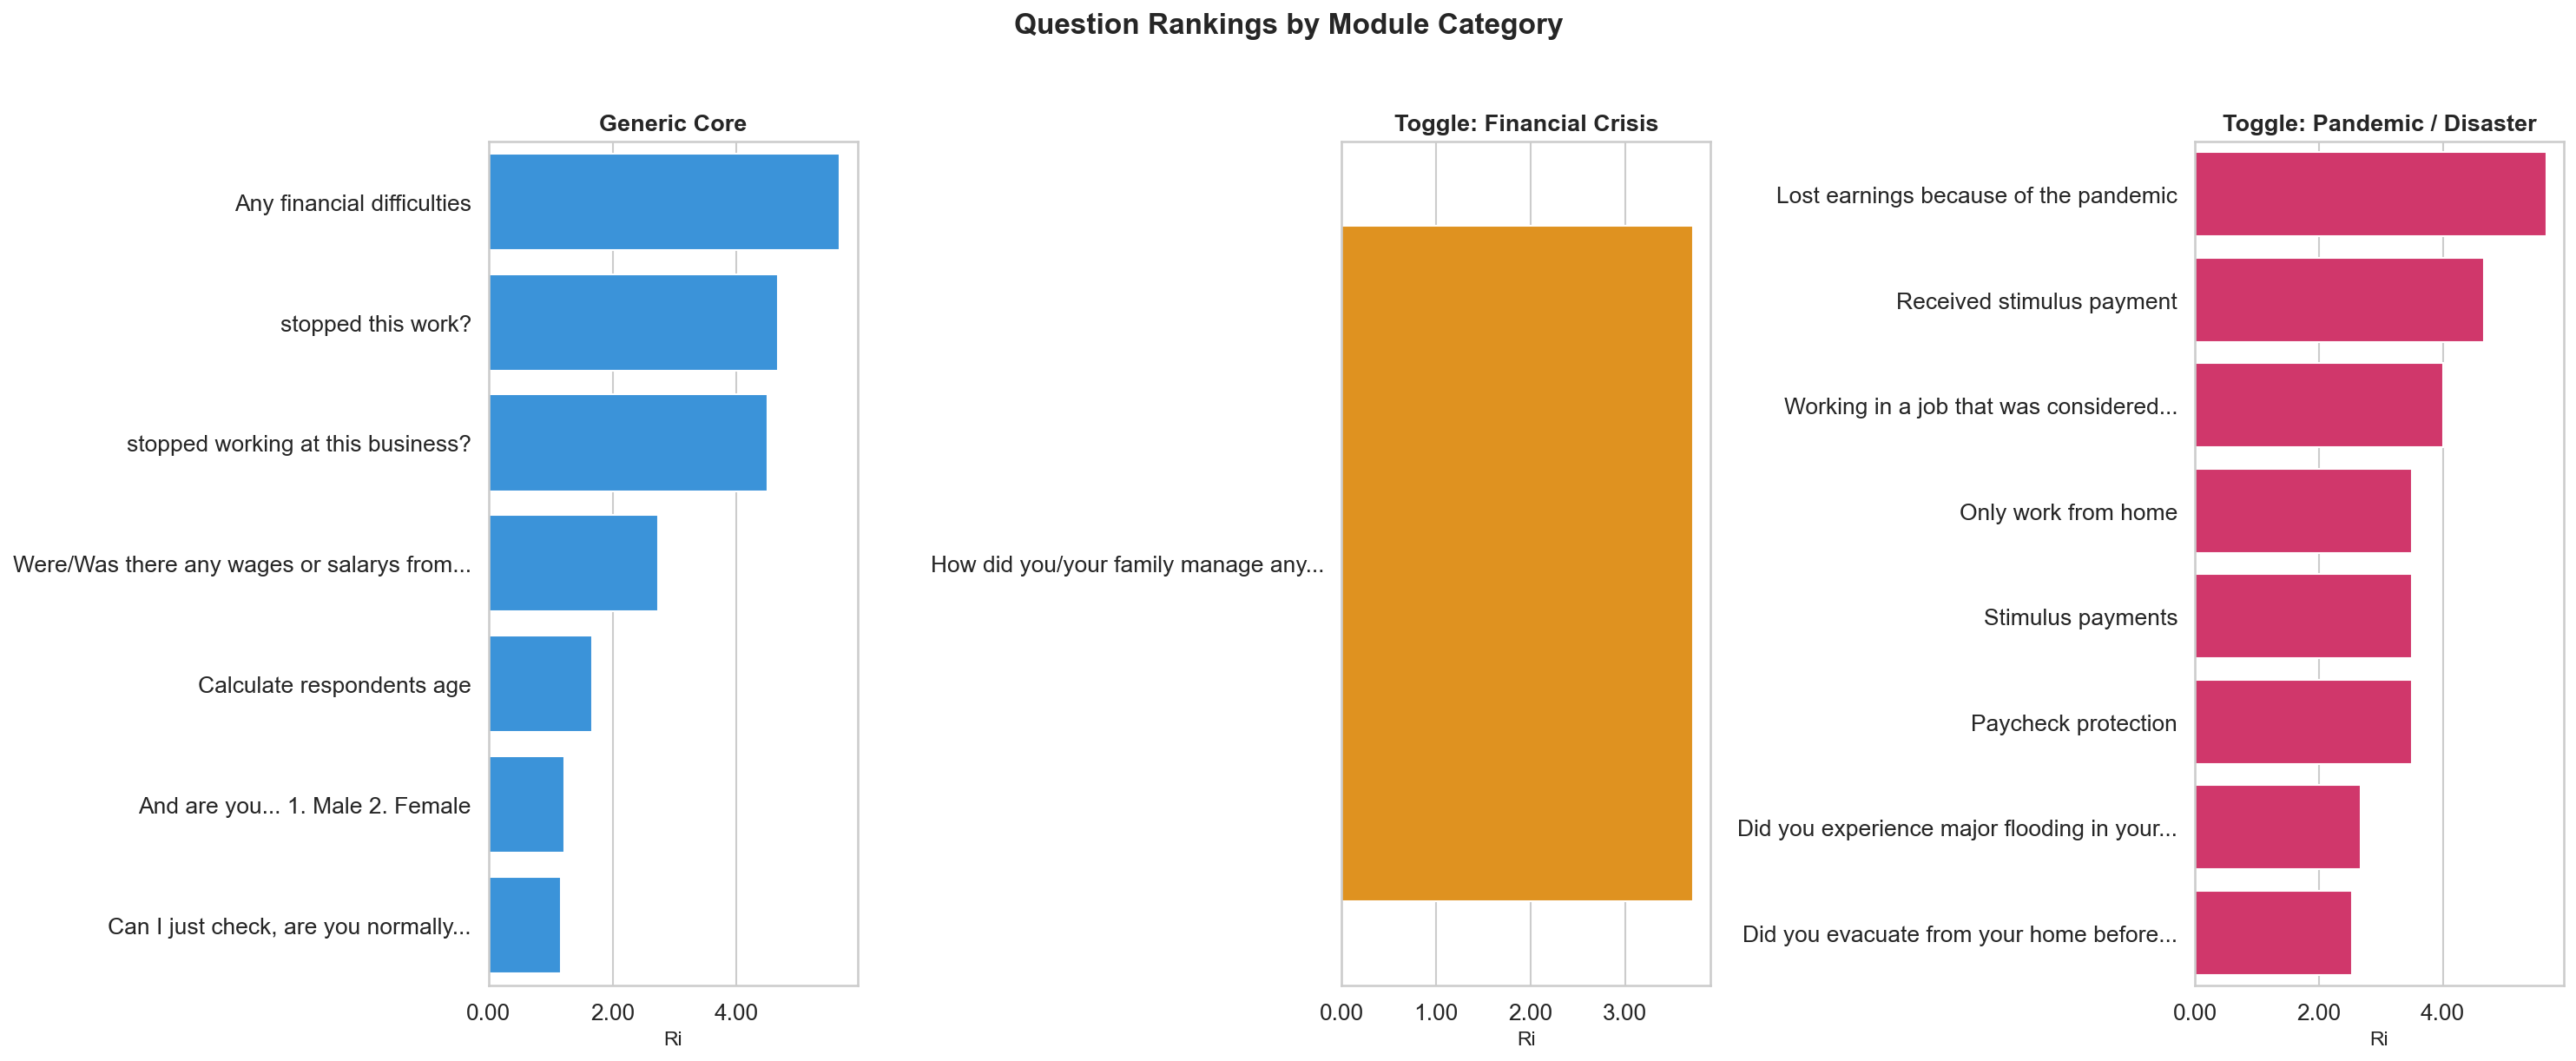

Saved: fig_toggle_comparison.png


In [54]:
# ──────────────────────────────────────────────────────────────────────────
# 8b. SIDE-BY-SIDE BAR CHART — Generic Core vs Toggle top questions
# ──────────────────────────────────────────────────────────────────────────

ordered_categories = [
    "Generic Core",
    "Toggle: Financial Crisis",
    "Toggle: Pandemic / Disaster",
    "Toggle Natural Disaster",
]
categories = [category for category in ordered_categories if category in df["toggle_category"].unique()]
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories) + 2, 8), sharey=False)
if len(categories) == 1:
    axes = [axes]

for ax, category in zip(axes, categories):
    subset = df[df["toggle_category"] == category].head(8).copy()
    if subset.empty:
        ax.set_title(category, fontsize=12, fontweight="bold")
        ax.text(0.5, 0.5, "No questions", transform=ax.transAxes, ha="center")
        continue
    subset["short_q"] = subset["question_text"].apply(
        lambda text: textwrap.shorten(text, width=45, placeholder="...")
    )
    sns.barplot(
        data=subset,
        y="short_q",
        x="Ri",
        color=toggle_palette.get(category, "#888888"),
        ax=ax,
    )
    ax.set_title(category, fontsize=13, fontweight="bold")
    ax.set_xlabel("Ri", fontsize=11)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.suptitle(
    "Question Rankings by Module Category",
    fontsize=16,
    fontweight="bold",
    y=1.02,
 )
plt.tight_layout()
plt.savefig("fig_toggle_comparison.png", bbox_inches="tight")
plt.show()
print("Saved: fig_toggle_comparison.png")

### 8c. Utility vs Burden — Efficiency Frontier

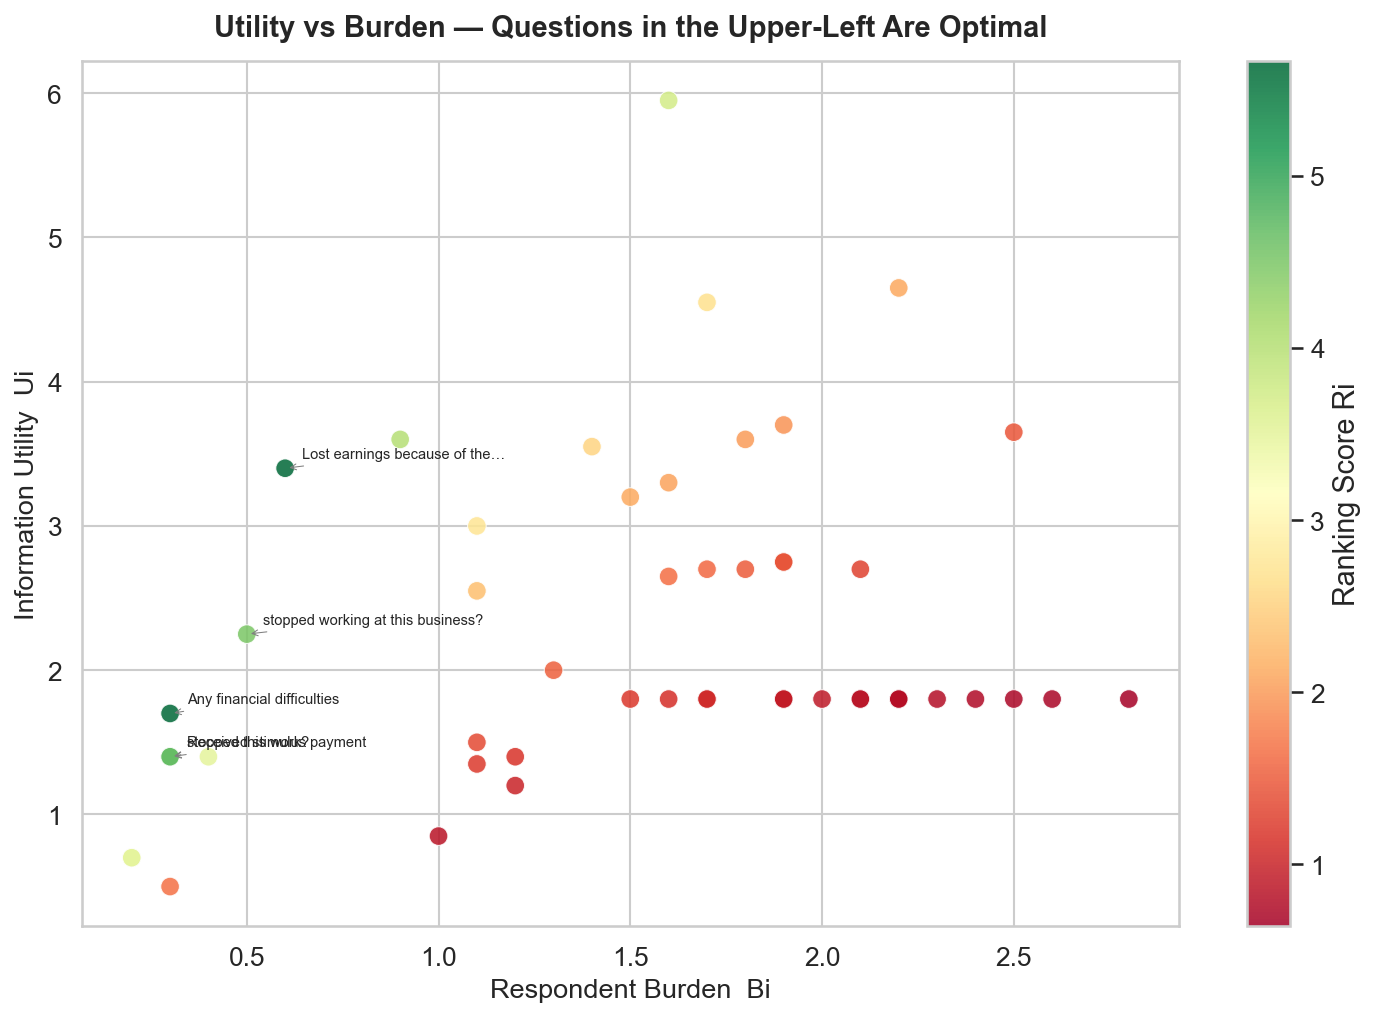

Saved: fig_utility_vs_burden.png


In [55]:
# ──────────────────────────────────────────────────────────────────────────
# 8c. SCATTER PLOT — Information Utility vs Respondent Burden
# ──────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    df["Bi"], df["Ui"],
    c=df["Ri"],
    cmap="RdYlGn",
    s=80,
    edgecolors="white",
    linewidth=0.5,
    alpha=0.85,
)
cbar = plt.colorbar(scatter, ax=ax, label="Ranking Score Ri")

# Annotate the top 5
for _, row in df.head(5).iterrows():
    ax.annotate(
        textwrap.shorten(row["question_text"], 35, placeholder="…"),
        (row["Bi"], row["Ui"]),
        fontsize=7,
        textcoords="offset points",
        xytext=(8, 5),
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.5),
    )

ax.set_xlabel("Respondent Burden  Bi", fontsize=13)
ax.set_ylabel("Information Utility  Ui", fontsize=13)
ax.set_title("Utility vs Burden — Questions in the Upper-Left Are Optimal",
             fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig_utility_vs_burden.png", bbox_inches="tight")
plt.show()
print("Saved: fig_utility_vs_burden.png")

### 8d. Crisis Construct Heatmap by Source

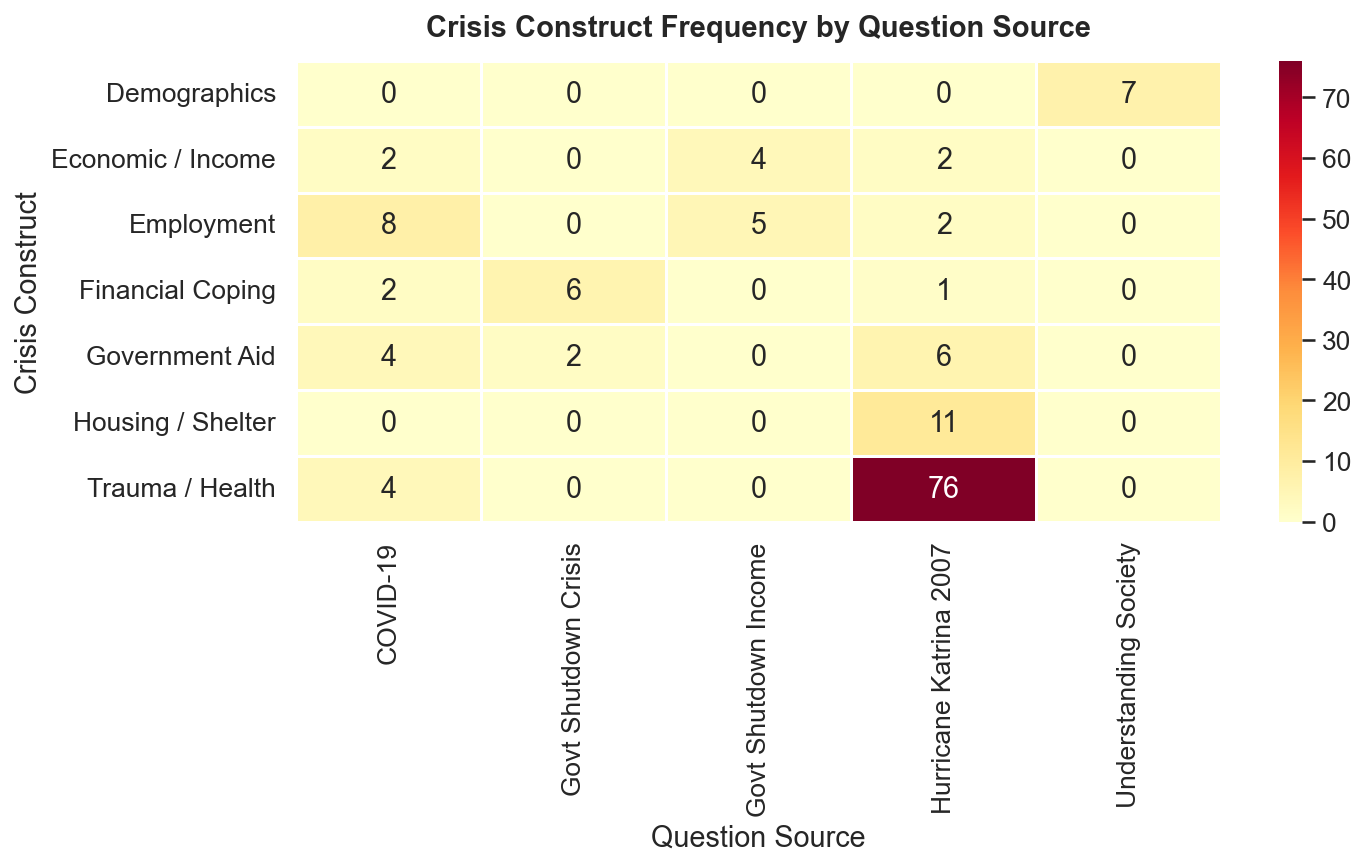

Constructs shown on heatmap: ['Demographics', 'Economic / Income', 'Employment', 'Financial Coping', 'Government Aid', 'Housing / Shelter', 'Trauma / Health']
Saved: fig_construct_heatmap.png


In [56]:
# ──────────────────────────────────────────────────────────────────────────
# 8d. HEATMAP — construct frequency by source
# ──────────────────────────────────────────────────────────────────────────

construct_source = []
for _, row in df.iterrows():
    for tag in row["tagged"]:
        construct_source.append({"construct": tag["construct"], "source": row["source"]})

cs_df = pd.DataFrame(construct_source)
if len(cs_df):
    pivot = cs_df.pivot_table(index="construct", columns="source", aggfunc="size", fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=ax)
    ax.set_title(
        "Crisis Construct Frequency by Question Source",
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    ax.set_ylabel("Crisis Construct")
    ax.set_xlabel("Question Source")
    plt.tight_layout()
    plt.savefig("fig_construct_heatmap.png", bbox_inches="tight")
    plt.show()
    print("Constructs shown on heatmap:", list(pivot.index))
    print("Saved: fig_construct_heatmap.png")

### 8e. Estimated Time Budget by Module Category

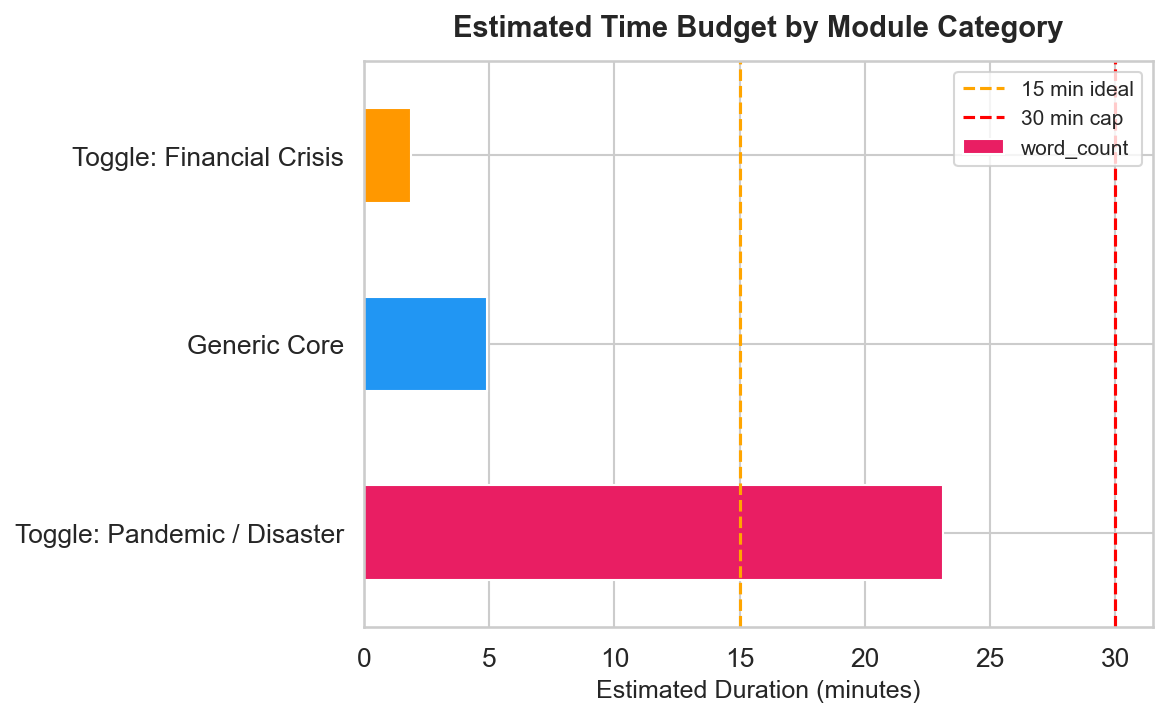

Saved: fig_time_budget.png


In [57]:
# ──────────────────────────────────────────────────────────────────────────
# 8e. STACKED BAR — estimated minutes per toggle category
# ──────────────────────────────────────────────────────────────────────────

selected = df[df["selected_for_module"]].copy()
time_budget = (
    selected
    .groupby("toggle_category")["word_count"]
    .sum()
    .mul(SECS_PER_WORD / 60)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
time_budget.plot.barh(
    color=[toggle_palette.get(category, "#888888") for category in time_budget.index],
    edgecolor="white",
    ax=ax,
 )
ax.axvline(x=15, color="orange", linestyle="--", linewidth=1.5, label="15 min ideal")
ax.axvline(x=30, color="red", linestyle="--", linewidth=1.5, label="30 min cap")
ax.set_xlabel("Estimated Duration (minutes)", fontsize=12)
ax.set_ylabel("")
ax.set_title(
    "Estimated Time Budget by Module Category",
    fontsize=14,
    fontweight="bold",
    pad=12,
 )
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig_time_budget.png", bbox_inches="tight")
plt.show()
print("Saved: fig_time_budget.png")

## 9. Export Final Ranked Question Table

In [58]:
# ──────────────────────────────────────────────────────────────────────────
# 9.  EXPORT — save ranked questions to CSV
# ──────────────────────────────────────────────────────────────────────────

export_cols = list(df.columns)
output_path = "/Users/namomac/Team-PSID/PSID_Ranked_Questions_v2.csv"

df[export_cols].to_csv(output_path, index=False)
print(f"Exported ranked questions to: {output_path}")
print(f"Total rows: {len(df)}")
print(f"Selected for module: {df['selected_for_module'].sum()}")
print(f"Columns exported ({len(export_cols)}): {export_cols}")

print("\n" + "=" * 70)
print("PIPELINE COMPLETE")
print("=" * 70)
print(f"Questions analysed:   {len(df)}")
print(f"Keywords extracted:   {df['n_keywords'].sum()}")
print(f"Constructs tagged:    {df['n_tagged'].sum()}")
print(f"Module selected:      {df['selected_for_module'].sum()} questions")
print(
    f"Estimated duration:   {df[df['selected_for_module']]['word_count'].sum() * SECS_PER_WORD / 60:.1f} min"
 )

Exported ranked questions to: /Users/namomac/Team-PSID/PSID_Ranked_Questions_v2.csv
Total rows: 52
Selected for module: 28
Columns exported (16): ['question_text', 'source', 'module_type', 'toggle_category', 'keywords', 'n_keywords', 'n_tagged', 'word_count', 'complexity', 'Ui', 'Bi', 'Ri', 'selected_for_module', 'crisis_origin', 'tagged', 'constructs']

PIPELINE COMPLETE
Questions analysed:   52
Keywords extracted:   282
Constructs tagged:    142
Module selected:      28 questions
Estimated duration:   29.9 min
